# Data Hub

This computational notebook provides an interactive framework for exploring NEON (National Ecological Observatory Network) weather station datasets alongside CLM (Community Land Model) outputs. By integrating observed meteorological data with model simulations, this environment allows for a comparative analysis of land-atmosphere interactions. The following instructions are designed to guide you through an initial assessment of the data, demonstrating the powerful analytical and visualization tools available within this workspace.

In [ ]:
!{sys.executable} -m pip install s3fs tqdm

In [ ]:
1+1

In [ ]:
import sys

import time

start_time = time.perf_counter()

# Takes about 10mins to install those libraries but its necessary to ensure those are available
!{sys.executable} -m pip install cartopy boto3 dask h5netcdf
#s3fs
end_time = time.perf_counter()

execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

In [ ]:
import xarray as xr
print("h5netcdf" in xr.backends.list_engines())

In [ ]:
#Import Libraries
%matplotlib inline

import os
import sys
import time
import datetime

import numpy as np
import pandas as pd
import xarray as xr

from glob import glob
from os.path import join, expanduser

import matplotlib
import matplotlib.pyplot as plt

from scipy import stats

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import requests

## Weather Stations

We allow 5 stations from now: please select from the list ['ABBY','CLBJ','CPER','KONZ','TALL']

In [5]:
url = "https://data.neonscience.org/api/v0/sites"
response = requests.get(url, timeout=20)
response.raise_for_status()

data = response.json()

target_sites = {"ABBY", "CLBJ", "CPER", "KONZ", "TALL"}

records = []

for site in data["data"]:
    code = site["siteCode"]
    if code in target_sites:
        records.append({
            "station": code,
            "name": site["siteName"],
            "lat": site["siteLatitude"],
            "lon": site["siteLongitude"],
            "state": site["stateCode"],
            "domain": site["domainCode"],
        })

neon_meta = pd.DataFrame(records).sort_values("station")
neon_meta


,station,name,lat,lon,state,domain
0,ABBY,Abby Road NEON,45.762439,-122.330317,WA,D16
1,CLBJ,Lyndon B. Johnson National Grassland NEON,33.401230,-97.570000,TX,D11
2,CPER,Central Plains Experimental Range NEON,40.815536,-104.745591,CO,D10
3,KONZ,Konza Prairie Biological Station NEON,39.100774,-96.563075,KS,D06
4,TALL,Talladega National Forest NEON,32.950470,-87.393259,AL,D08


/usr/local/lib64/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib64/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib64/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib64/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


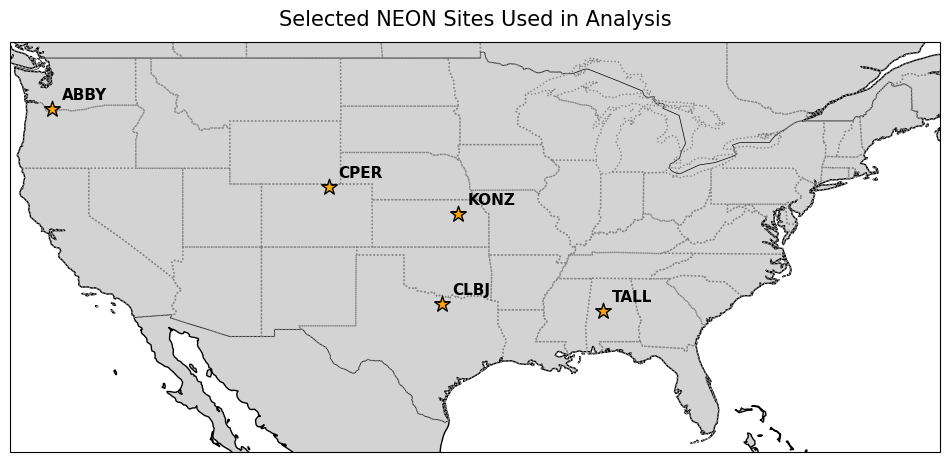

In [6]:
# Station metadata (static, reproducible)
stations = neon_meta

# Create map
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Geographic context
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, edgecolor="gray", linestyle=":")

# CONUS extent
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# Plot stations
ax.scatter(
    stations.lon,
    stations.lat,
    s=140,
    marker="*",
    color="orange",
    edgecolor="black",
    transform=ccrs.PlateCarree(),
    zorder=5,
)

# Labels
for _, row in stations.iterrows():
    ax.text(
        row.lon + 0.6,
        row.lat + 0.6,
        row.station,
        transform=ccrs.PlateCarree(),
        fontsize=11,
        fontweight="bold",
        zorder=6,
    )

plt.title("Selected NEON Sites Used in Analysis", fontsize=15, pad=12)
plt.show()


## 2. Explore CTSM model data 

This step guides you through exploring the data from CLM simulations. There are countless ways of analyzing and processing model data. The below steps step through where to find model data and creates a plot to visualize some model data.

Notice that each line includes the location of the file (/home/user/archive/{simulation_name}/lnd/hist/) and file name. The file names are automatically generated and are composed of:

the simulation name, which includes:
the NEON site
the type of simulation
The simulation you ran is "transient". This means the model was initialized and ran for the full length of available data. The initial conditions files for the transient tower simulations were created by cycling over 2018-2019 tower meteorological data.
the date of simulated data
The files are saved in netcdf format (denoted with the .nc file extension), a file format commonly used for storing large, multi-dimensional scientific variables. Netcdf files are platform independent and self-describing; each file includes metadata that describes the data, including: variables, dimensions, and attributes. You can explore the files more in the NEON_Simple_Visualization_Tutorial

The NEON tower simulations generate two types of files:

- *h0*: Variables that are averaged monthly. One file is available for every month of the simulation. These files include hundreds of variables.
- *h1*: Variables that are recorded every 30 minutes. Values are aggregated into one file for each day of the simulation. Each file includes 48 data points for selected variables.
Note that you can also find the model data in the 'Simulation' folder on your desktop, which was created as part of this tutorial.

In [9]:
from data_access import list_objects_under_prefix, get_s3_client, test_s3_connection, open_ctsm_hist_from_s3, plot_soil_profile_timeseries

In [10]:
# This part takes 75.04530649300432 seconds

import time

start_time = time.perf_counter()

bucket_name = "clm-demonstration"
neon_site = "ABBY"
year = "2019"

# Use hist prefix for the connectivity check
hist_prefix = f"archive_1/{neon_site}.transient/lnd/hist/*{year}*.nc"

# ---- Connect ----
s3 = get_s3_client()
if not test_s3_connection(s3, bucket_name, hist_prefix):
    raise RuntimeError("S3 connection test failed")

# Optional: quick peek at keys
keys = list_objects_under_prefix(s3, bucket_name, hist_prefix, dry_run=True)
print("\nPreview keys under hist prefix (first page):")
for k in keys[:10]:
    print(" -", k)

# ---- Open dataset ----
ds_ctsm = open_ctsm_hist_from_s3(
    input_label = 'transient',
    s3_client=s3,
    bucket_name=bucket_name,
    neon_site=neon_site,
    year=year,
    # If your files ever become NetCDF-4/HDF5, set engine="h5netcdf"
    engine="scipy",
    preview_n=10,
    parallel=False,
    chunks=None,
)

print("\nDataset opened successfully:")
print(ds_ctsm)
print("\nDims:", dict(ds_ctsm.dims))
print("\nVars (first 25):", list(ds_ctsm.data_vars)[:25])

# Measure the execution time over a specified number of runs
# timeit.timeit() returns the total time taken for all executions
end_time = time.perf_counter()

execution_time = end_time - start_time
print(f"Execution time: {execution_time} seconds")

/usr/local/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


⚠️ Connected, but prefix is empty: clm-demonstration/archive_1/ABBY.transient/lnd/hist/*2019*.nc

Preview keys under hist prefix (first page):
All Simulation files: [365 files]
First files:
  archive_1/ABBY.transient/lnd/hist/ABBY.transient.clm2.h1.2019-01-01-00000.nc
  archive_1/ABBY.transient/lnd/hist/ABBY.transient.clm2.h1.2019-01-02-00000.nc
  archive_1/ABBY.transient/lnd/hist/ABBY.transient.clm2.h1.2019-01-03-00000.nc
  archive_1/ABBY.transient/lnd/hist/ABBY.transient.clm2.h1.2019-01-04-00000.nc
  archive_1/ABBY.transient/lnd/hist/ABBY.transient.clm2.h1.2019-01-05-00000.nc
  archive_1/ABBY.transient/lnd/hist/ABBY.transient.clm2.h1.2019-01-06-00000.nc
  archive_1/ABBY.transient/lnd/hist/ABBY.transient.clm2.h1.2019-01-07-00000.nc
  archive_1/ABBY.transient/lnd/hist/ABBY.transient.clm2.h1.2019-01-08-00000.nc
  archive_1/ABBY.transient/lnd/hist/ABBY.transient.clm2.h1.2019-01-09-00000.nc
  archive_1/ABBY.transient/lnd/hist/ABBY.transient.clm2.h1.2019-01-10-00000.nc
Reading all simulati

/tmp/ipykernel_111/1025310643.py:40: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("\nDims:", dict(ds_ctsm.dims))


In [11]:
ds_ctsm

<xarray.Dataset> Size: 9MB
Dimensions:       (time: 17520, hist_interval: 2, lndgrid: 1, levsoi: 20,
                   levdcmp: 25, levgrnd: 25, levlak: 10)
Coordinates:
  * levgrnd       (levgrnd) float32 100B 0.01 0.04 0.09 ... 19.48 28.87 42.0
  * levsoi        (levsoi) float32 80B 0.01 0.04 0.09 0.16 ... 5.95 6.94 8.03
  * levlak        (levlak) float32 40B 0.05 0.6 2.1 4.6 ... 25.6 34.33 44.78
  * levdcmp       (levdcmp) float32 100B 0.01 0.04 0.09 ... 19.48 28.87 42.0
  * time          (time) datetime64[ns] 140kB 2019-01-01 ... 2019-12-31T23:30...
Dimensions without coordinates: hist_interval, lndgrid
Data variables: (12/32)
    mcdate        (time) int32 70kB dask.array<chunksize=(48,), meta=np.ndarray>
    mcsec         (time) int32 70kB dask.array<chunksize=(48,), meta=np.ndarray>
    mdcur         (time) int32 70kB dask.array<chunksize=(48,), meta=np.ndarray>
    mscur         (time) int32 70kB dask.array<chunksize=(48,), meta=np.ndarray>
    nstep         (time) int32 70kB dask.array<chunksize=(48,), meta=np.ndarray>
    time_bounds   (time, hist_interval) datetime64[ns] 280kB dask.array<chunksize=(48, 2), meta=np.ndarray>
    ...            ...
    HR            (time, lndgrid) float32 70kB dask.array<chunksize=(48, 1), meta=np.ndarray>
    NET_NMIN_vr   (time, levdcmp, lndgrid) float32 2MB dask.array<chunksize=(48, 25, 1), meta=np.ndarray>
    SNOW_DEPTH    (time, lndgrid) float32 70kB dask.array<chunksize=(48, 1), meta=np.ndarray>
    SOILC_vr      (time, levsoi, lndgrid) float32 1MB dask.array<chunksize=(48, 20, 1), meta=np.ndarray>
    TBOT          (time, lndgrid) float32 70kB dask.array<chunksize=(48, 1), meta=np.ndarray>
    TSOI          (time, levgrnd, lndgrid) float32 2MB dask.array<chunksize=(48, 25, 1), meta=np.ndarray>
Attributes: (12/101)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              created on 10/16/25 00:19:36
    source:                               Community Terrestrial Systems Model
    hostname:                             container
    ...                                   ...
    cft_irrigated_tropical_corn:          62
    cft_tropical_soybean:                 63
    cft_irrigated_tropical_soybean:       64
    time_period_freq:                     minute_30
    Time_constant_3Dvars_filename:        ./ABBY.transient.clm2.h1.2018-01-01...
    Time_constant_3Dvars:                 ZSOI:DZSOI:WATSAT:SUCSAT:BSW:HKSAT:...

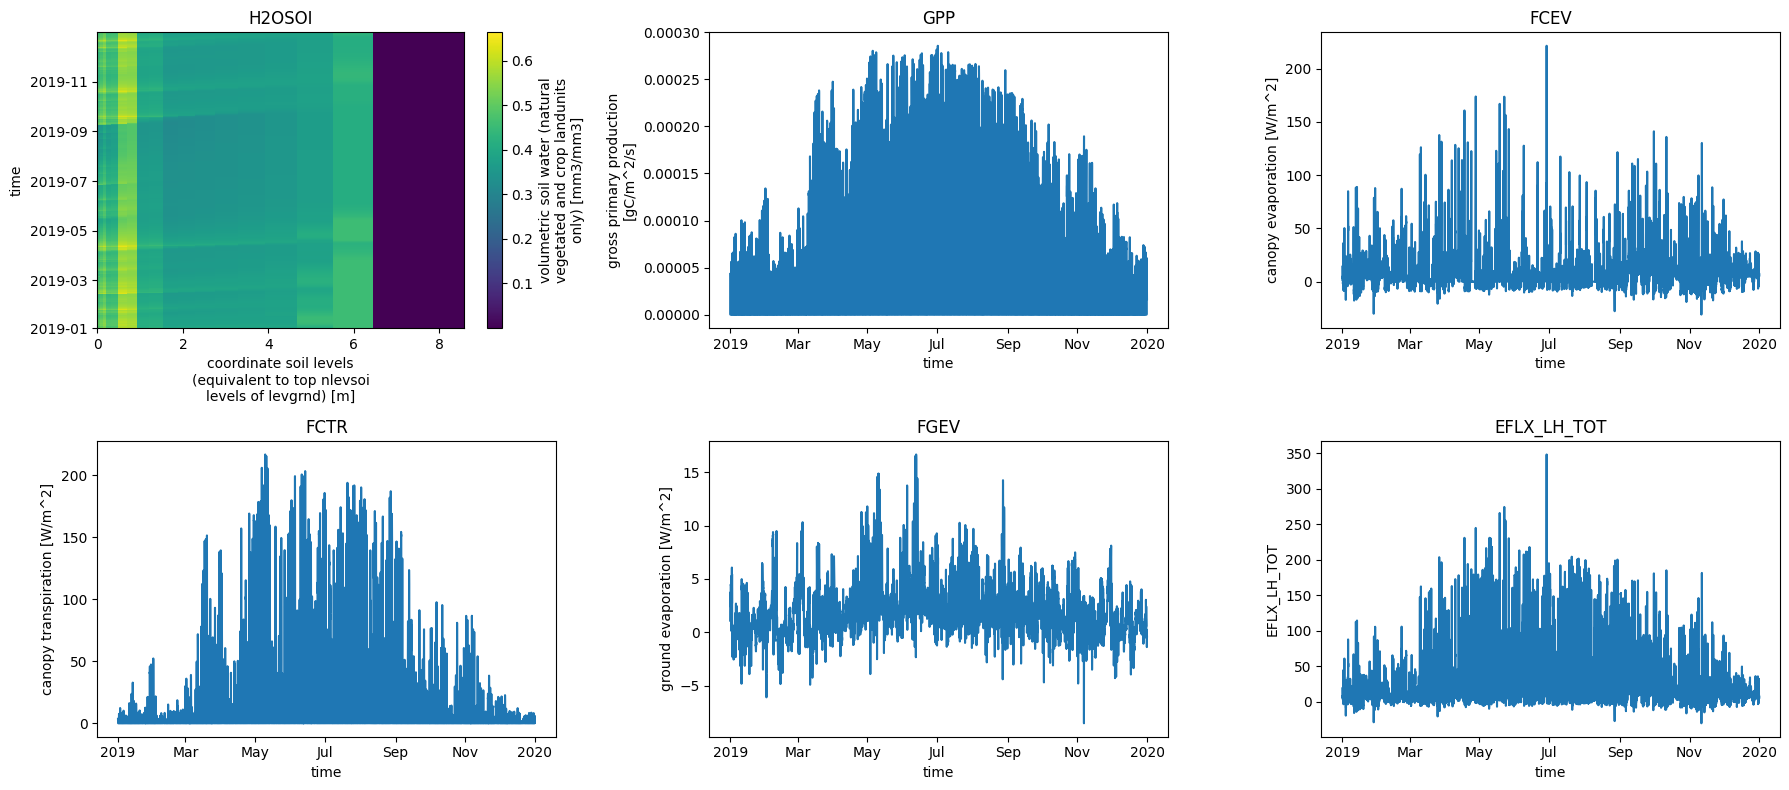

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 8))

# First entry for soil moisture
ds_ctsm['H2OSOI'].plot(ax=axes[0, 0])
axes[0, 0].set_title('H2OSOI')

ds_ctsm['GPP'].plot(ax=axes[0, 1]) # GPP 
axes[0, 1].set_title('GPP')

#### 𝐿𝑎𝑡𝑒𝑛𝑡 𝐻𝑒𝑎𝑡 𝐹𝑙𝑢𝑥 = 𝑇𝑟𝑎𝑛𝑠𝑝𝑖𝑟𝑎𝑡𝑖𝑜𝑛 + 𝐶𝑎𝑛𝑜𝑝𝑦 𝐸𝑣𝑎𝑝𝑜𝑟𝑎𝑡𝑖𝑜𝑛 + 𝐺𝑟𝑜𝑢𝑛𝑑 𝐸𝑣𝑎𝑝𝑜𝑟𝑎𝑡𝑖𝑜𝑛
ds_ctsm['FCEV'].plot(ax=axes[0, 2])
axes[0, 2].set_title('FCEV')

# Second row
ds_ctsm['FCTR'].plot(ax=axes[1, 0])
axes[1, 0].set_title('FCTR')

ds_ctsm['FGEV'].plot(ax=axes[1, 1])
axes[1, 1].set_title('FGEV')

ds_ctsm['EFLX_LH_TOT'] = ds_ctsm['FCEV']+ds_ctsm['FCTR']+ds_ctsm['FGEV']
ds_ctsm['EFLX_LH_TOT'].plot(ax=axes[1, 2])
axes[1, 2].set_title('EFLX_LH_TOT')

# Leave the last subplot blank or turn it off


plt.tight_layout()
plt.show()


In [1]:
ds = plot_soil_profile_timeseries(
    neon_site="ABBY",
    var="TSOI",
    year=2018
    )
plt.show()

NameError: name 'plot_soil_profile_timeseries' is not defined